# SCOPE ξ(r) Convergence — §5.5 Variance of the SCOPE Estimator

In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('../../../../src').resolve()))
from config import get_snapshot_redshift

try:
    from utils.matplotlib_config import setconfig
    setconfig()
except ImportError:
    pass

In [2]:
DATA_ROOT = Path('../../../../data/2pcf/scope_xi')
MODEL     = 'lc16'
SIM       = 'L800'
N_REF     = 1024   # full-box Corrfunc reference (pending — falls back to max available n)

# Quick-look config (sections 1–2)
QK_IZ        = 155
QK_MSTAR_TAG = 'mstar9.0'
QK_Z         = get_snapshot_redshift(f'iz{QK_IZ}', 'L800')

# n values to show in detail and headline plots
PLOT_N     = [2,4,8,16,32,64, 128, 256]#[2, 8, 32, 128, 256]
HEADLINE_N = [2,4,8,16,32,64, 128, 256]#[4, 16, 64, 256]
# n=128 and n=256 are infeasible for mstar_none: runtime >> cosma8 8h/16h limits
PLOT_N_MSTAR_NONE = [n for n in PLOT_N if n < 128]

print(f'Data root:   {DATA_ROOT}')
print(f'Quick-look:  iz{QK_IZ}  →  z = {QK_Z:.3f}  ({QK_MSTAR_TAG})')

Data root:   ../../data/2pcf/scope_xi
Quick-look:  iz155  →  z = 1.496  (mstar9.0)


In [3]:
def load_and_aggregate(iz: int, mstar_tag: str) -> pd.DataFrame | None:
    """Load all scope_xi CSVs for one (iz, mstar_tag) and aggregate over seeds.

    The n=1024 Corrfunc full-box run is always used as the reference.  Residual
    columns (frac_diff_*, dlog_*) will be NaN until that reference is available.

    Returns a DataFrame with per-(n_subvol, bin_idx) statistics, or None if no data.
    """
    base = DATA_ROOT / MODEL / f'iz{iz}' / mstar_tag
    if not base.is_dir():
        return None

    files = sorted(base.glob(f'n*/seed*/scope_xi_{SIM}_iz{iz}.csv'))
    if not files:
        return None

    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df = df.drop_duplicates(subset=['selection_seed', 'n_subvol', 'bin_idx'])

    if N_REF not in df['n_subvol'].values:
        print(f'  WARNING: n={N_REF} reference not yet available for iz{iz} {mstar_tag} — residuals will be empty')

    # Compute statistics *only* over strictly positive ξ values when forming spreads/counts.
    # This avoids including zero or negative ξ in error/spread calculations.
    g = (df
         .groupby(['n_subvol', 'bin_idx', 'r_mid'], as_index=False)
         .agg(
             xi_corr_mean   = ('xi_corrected', lambda x: next((val for val in x if val != 0), np.nan)) ,#('xi_corrected', 'mean'),
             xi_corr_std    = ('xi_corrected', lambda x: float(np.nanstd(x[x > 0])) if np.any(x > 0) else np.nan),
             xi_naive_mean  = ('xi_naive',lambda x: next((val for val in x if val != 0), np.nan)), #('xi_naive',     'mean'),
             xi_naive_std   = ('xi_naive',     lambda x: float(np.nanstd(x[x > 0])) if np.any(x > 0) else np.nan),
             xi_corr_p16    = ('xi_corrected', lambda x: float(np.nanpercentile(x[x > 0], 16)) if np.any(x > 0) else np.nan),
             xi_corr_p84    = ('xi_corrected', lambda x: float(np.nanpercentile(x[x > 0], 84)) if np.any(x > 0) else np.nan),
             n_seeds_corr   = ('xi_corrected', lambda x: int(np.count_nonzero(x > 0))),
             n_seeds_naive  = ('xi_naive',     lambda x: int(np.count_nonzero(x > 0))),
         ))

    # Error on the mean using only the positive-value counts; leave NaN where no positive samples.
    g['xi_corr_err']  = np.where(g['n_seeds_corr'] > 0, g['xi_corr_std']  / np.sqrt(g['n_seeds_corr']),  np.nan)
    g['xi_naive_err'] = np.where(g['n_seeds_naive'] > 0, g['xi_naive_std'] / np.sqrt(g['n_seeds_naive']), np.nan)

    # Merge reference values using bin_idx (not r_mid, which can differ by rounding)
    ref = (g[g['n_subvol'] == N_REF][['bin_idx', 'xi_corr_mean', 'r_mid']]
             .rename(columns={'xi_corr_mean': 'xi_ref', 'r_mid': 'r_mid_ref'}))
    g = g.merge(ref, on='bin_idx', how='left')
    # Use reference r_mid (more accurate since it's from the full box)
    g['r_mid'] = g['r_mid_ref'].fillna(g['r_mid'])
    g = g.drop(columns=['r_mid_ref'])

    # Fractional residual: (xi - xi_ref) / |xi_ref|
    safe_ref = np.where(np.abs(g['xi_ref']) > 0, g['xi_ref'], np.nan)
    g['frac_diff_corr']  = (g['xi_corr_mean']  - g['xi_ref']) / np.abs(safe_ref)
    g['frac_diff_naive'] = (g['xi_naive_mean'] - g['xi_ref']) / np.abs(safe_ref)

    # log-ratio where both are positive (for threshold plot)
    pos_c = (g['xi_corr_mean'] > 0) & (g['xi_ref'] > 0)
    g['dlog_corr']  = np.where(pos_c, np.log10(g['xi_corr_mean'] / g['xi_ref']),  np.nan)
    pos_n = (g['xi_naive_mean'] > 0) & (g['xi_ref'] > 0)
    g['dlog_naive'] = np.where(pos_n, np.log10(g['xi_naive_mean'] / g['xi_ref']), np.nan)

    return g


def _n_colors(n_values):
    cmap = mpl.colormaps['plasma']
    return [cmap(0.1 + 0.75 * i / max(len(n_values) - 1, 1)) for i in range(len(n_values))]


def _mstar_label(mstar_tag: str) -> str:
    if mstar_tag == 'mstar_none':
        return 'no $M_*$ cut'
    val = mstar_tag.replace('mstar', '')
    return f'$M_*/M_\\odot h^{{-1}} > {val}$'


print('Helpers defined.')

Helpers defined.


## 5.5 Variance of the SCOPE Estimator

Sections 5.1–5.4 characterise the *bias* of the SCOPE estimator: the deviation of the ensemble-mean estimate from the full-box reference. A complementary question relevant to likelihood-based inference is whether the SCOPE correction also reduces the seed-to-seed *variance*. Because the weight $\alpha = m/k < 1$ suppresses the auto-pair contribution from one-halo pairs (equation 10), and those pairs are both the most inflated and the most shot-noise-dominated, the variance should fall simultaneously with the bias.

To quantify this, 30 independent random sub-volume selections (seeds 1001–1030) were computed for each cell $(N_{\rm subvol},\,M_*,\,z)$ using `submit_scope_xi_variance.sh`. The seed-audit table below confirms 30 seeds per cell. The three figures in the cells that follow address (i) how $\sigma/|\xi_{\rm ref}|$ scales with $N_{\rm subvol}$ compared to $1/\sqrt{N}$, (ii) how the ratio $\sigma_{\rm SCOPE}/\sigma_{\rm naïve}$ depends on separation, and (iii) where bias and variance cross over.


/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


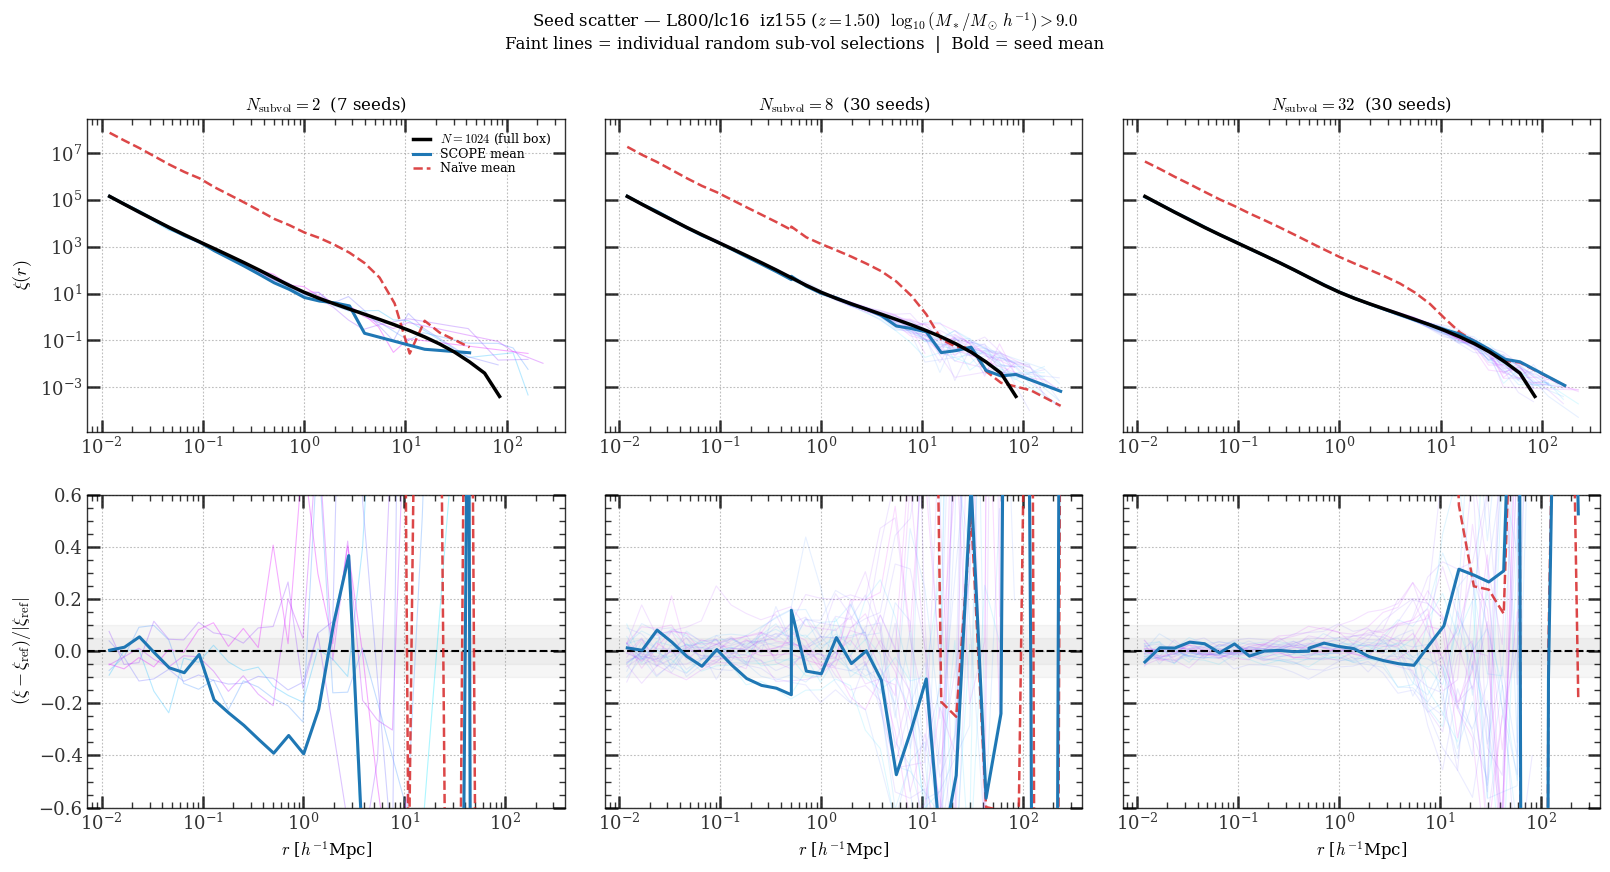

No n=1024 reference for iz155 mstar_none — skipping


In [18]:

# ─── Section 5.5: Seed Scatter / Deterministic vs Random Sub-volumes ───────────

def load_raw(iz: int, mstar_tag: str, n_subvol: int) -> pd.DataFrame | None:
    """Load per-seed CSVs for (iz, mstar_tag, n_subvol) without aggregation.

    Excludes seed1000 (Corrfunc full-box reference).
    Returns one row per (seed, bin_idx), or None if no files found.
    """
    base  = DATA_ROOT / MODEL / f'iz{iz}' / mstar_tag
    files = [f for f in sorted(base.glob(f'n{n_subvol}/seed*/scope_xi_{SIM}_iz{iz}.csv'))
             if 'seed1000' not in str(f)]
    if not files:
        return None
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def seed_scatter_plot(iz: int, mstar_tag: str, n_values: list[int]) -> None:
    """Individual seed realisations of ξ(r) vs SCOPE mean and full-box reference.

    Top row  — ξ(r): faint = individual seeds, bold blue = SCOPE seed-mean,
               bold red dashed = naïve seed-mean, black = full-box reference.
    Bottom row — fractional residual vs full box, same colour scheme.

    Shows that SCOPE collapses all random sub-volume selections onto an unbiased
    estimate regardless of which partitions are chosen (paper §5.5).
    """
    z     = get_snapshot_redshift(f'iz{iz}', 'L800')
    g_agg = load_and_aggregate(iz, mstar_tag)
    if g_agg is None:
        print(f'No data: iz{iz} {mstar_tag}')
        return
    avail = sorted(g_agg['n_subvol'].unique())
    if N_REF not in avail:
        print(f'No n={N_REF} reference for iz{iz} {mstar_tag} — skipping')
        return

    ref        = g_agg[g_agg['n_subvol'] == N_REF].sort_values('r_mid')
    ref_lookup = ref.set_index('bin_idx')['xi_corr_mean'].to_dict()

    n_values_ok = [n for n in n_values if n in avail and n != N_REF]
    if not n_values_ok:
        print(f'None of {n_values} available for iz{iz} {mstar_tag}')
        return

    ncols = len(n_values_ok)
    fig, axes = plt.subplots(2, ncols, figsize=(5.5 * ncols, 9), sharey='row')
    if ncols == 1:
        axes = axes.reshape(2, 1)

    for col_idx, n in enumerate(n_values_ok):
        ax_top = axes[0, col_idx]
        ax_bot = axes[1, col_idx]
        first  = (col_idx == 0)

        # Full-box reference
        ref_pos = ref[ref['xi_corr_mean'] > 0]
        if not ref_pos.empty:
            ax_top.plot(ref_pos['r_mid'], ref_pos['xi_corr_mean'],
                        color='black', lw=2.5, zorder=10,
                        label=(f'$N={N_REF}$ (full box)' if first else '_nolegend_'))
        ax_bot.axhline(0, color='black', lw=1.5, ls='--', zorder=5)
        for lev in [0.05, 0.10]:
            ax_bot.axhspan(-lev, lev, color='grey', alpha=0.07, zorder=0)

        # Individual seeds
        raw = load_raw(iz, mstar_tag, n)
        if raw is not None:
            seeds      = sorted(raw['selection_seed'].unique())
            seed_alpha = max(0.15, min(0.5, 2.5 / max(len(seeds), 1)))
            seed_cmap  = mpl.colormaps['cool'](np.linspace(0.1, 0.9, len(seeds)))
            for seed, scol in zip(seeds, seed_cmap):
                sub = raw[raw['selection_seed'] == seed].sort_values('r_mid')
                pos = sub['xi_corrected'] > 0
                ax_top.plot(sub.loc[pos, 'r_mid'], sub.loc[pos, 'xi_corrected'],
                            color=scol, lw=0.8, alpha=seed_alpha, zorder=2)
                sub2 = sub.copy()
                sub2['xi_ref'] = sub2['bin_idx'].map(ref_lookup)
                valid = sub2[(sub2['xi_corrected'] > 0) & (sub2['xi_ref'] > 0)]
                if not valid.empty:
                    frac = (valid['xi_corrected'] - valid['xi_ref']) / valid['xi_ref'].abs()
                    ax_bot.plot(valid['r_mid'], frac,
                                color=scol, lw=0.8, alpha=seed_alpha, zorder=2)
            n_seeds = len(seeds)
        else:
            n_seeds = 0

        # Seed-aggregated means from g_agg
        agg_n  = g_agg[g_agg['n_subvol'] == n].sort_values('r_mid')
        pos_c  = agg_n['xi_corr_mean']  > 0
        pos_na = agg_n['xi_naive_mean'] > 0
        if pos_c.any():
            ax_top.plot(agg_n.loc[pos_c, 'r_mid'], agg_n.loc[pos_c, 'xi_corr_mean'],
                        color='C0', lw=2.2, zorder=8,
                        label=('SCOPE mean' if first else '_nolegend_'))
        if pos_na.any():
            ax_top.plot(agg_n.loc[pos_na, 'r_mid'], agg_n.loc[pos_na, 'xi_naive_mean'],
                        color='C3', lw=1.8, ls='--', alpha=0.85, zorder=7,
                        label=('Naïve mean' if first else '_nolegend_'))
        fin_c = agg_n['frac_diff_corr'].notna()
        fin_n = agg_n['frac_diff_naive'].notna()
        if fin_c.any():
            ax_bot.plot(agg_n.loc[fin_c, 'r_mid'], agg_n.loc[fin_c, 'frac_diff_corr'],
                        color='C0', lw=2.2, zorder=8)
        if fin_n.any():
            ax_bot.plot(agg_n.loc[fin_n, 'r_mid'], agg_n.loc[fin_n, 'frac_diff_naive'],
                        color='C3', lw=1.8, ls='--', alpha=0.85, zorder=7)

        ax_top.set_xscale('log'); ax_top.set_yscale('log')
        ax_top.set_title(f'$N_{{\\rm subvol}} = {n}$  ({n_seeds} seeds)', fontsize=12)
        ax_bot.set_xscale('log')
        ax_bot.set_xlabel(r'$r$ [$h^{-1}$Mpc]', fontsize=12)
        ax_bot.set_ylim(-0.6, 0.6)

    axes[0, 0].set_ylabel(r'$\xi(r)$', fontsize=13)
    axes[1, 0].set_ylabel(r'$(\xi - \xi_{\rm ref})/|\xi_{\rm ref}|$', fontsize=13)
    axes[0, 0].legend(fontsize=9, loc='upper right')

    fig.suptitle(
        f'Seed scatter — {SIM}/{MODEL}  iz{iz} ($z={z:.2f}$)  {_mstar_label(mstar_tag)}\n'
        r'Faint lines = individual random sub-vol selections  |  Bold = seed mean',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


# Quick-look config: N = 2, 8, 32 (covers 1-halo–dominated → transition → 2-halo)
seed_scatter_plot(QK_IZ, QK_MSTAR_TAG, [2, 8, 32])

# Higher-density sample to compare how seed variance scales with catalogue size
seed_scatter_plot(QK_IZ, 'mstar_none', [2, 8, 32])


In [19]:
# ─── Variance Investigation ──────────────────────────────────────────────────
# Extra seeds from submit_scope_xi_variance.sh top up each cell to 30 seeds.
# Cells below degrade gracefully with fewer seeds.

VARIANCE_IZ         = 155
VARIANCE_MSTAR_TAGS = ['mstar9.0', 'mstar10.0']
VARIANCE_N_VALUES   = [4, 8, 16, 32, 64, 128]
VARIANCE_SAVE_DIR   = Path('../../../../_plots/scope_xi_variance')
VARIANCE_SAVE_DIR.mkdir(parents=True, exist_ok=True)


def load_raw_seeds(iz: int, mstar_tag: str,
                   n_values: list[int] | None = None) -> pd.DataFrame | None:
    """All per-seed CSVs (excluding n=N_REF Corrfunc reference)."""
    base = DATA_ROOT / MODEL / f'iz{iz}' / mstar_tag
    if not base.is_dir():
        return None
    files = [f for f in sorted(base.glob(f'n*/seed*/scope_xi_{SIM}_iz{iz}.csv'))
             if 'seed1000' not in str(f)]
    if n_values is not None:
        files = [f for f in files
                 if int(f.parent.parent.name.lstrip('n')) in n_values]
    if not files:
        return None
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def compute_variance_stats(
    iz: int,
    mstar_tag: str,
    n_values: list[int] | None = None,
) -> pd.DataFrame | None:
    """Per-(n_subvol, bin_idx) variance statistics across seeds.

    Returns: n_subvol, bin_idx, r_mid, n_seeds,
      sigma_corr, sigma_naive, mean_corr, mean_naive, xi_ref,
      cv_corr, cv_naive, rel_sigma_corr, rel_sigma_naive, variance_ratio.
    """
    raw = load_raw_seeds(iz, mstar_tag, n_values)
    if raw is None:
        return None
    g_agg = load_and_aggregate(iz, mstar_tag)
    if g_agg is None or N_REF not in g_agg['n_subvol'].values:
        print(f'  No n={N_REF} reference for iz{iz} {mstar_tag}')
        return None
    ref = (g_agg[g_agg['n_subvol'] == N_REF][['bin_idx', 'xi_corr_mean']]
             .rename(columns={'xi_corr_mean': 'xi_ref'}))

    records = []
    ns = sorted(n for n in raw['n_subvol'].unique() if n != N_REF)
    if n_values:
        ns = [n for n in ns if n in n_values]

    for n in ns:
        sub_n = raw[raw['n_subvol'] == n]
        for bin_idx, sub_b in sub_n.groupby('bin_idx'):
            r_mid   = float(sub_b['r_mid'].iloc[0])
            xc      = sub_b['xi_corrected'].values
            xn      = sub_b['xi_naive'].values
            xc_pos  = xc[xc > 0]
            xn_pos  = xn[xn > 0]
            n_seeds = len(sub_b['selection_seed'].unique())
            xi_ref_rows = ref.loc[ref['bin_idx'] == bin_idx, 'xi_ref']
            xi_ref_val  = float(xi_ref_rows.iloc[0]) if len(xi_ref_rows) else np.nan

            def _safe(fn, arr):
                return float(fn(arr)) if len(arr) >= 3 else np.nan

            sc = _safe(np.std,  xc_pos)
            sn = _safe(np.std,  xn_pos)
            mc = _safe(np.mean, xc_pos)
            mn = _safe(np.mean, xn_pos)
            ref_ok = np.isfinite(xi_ref_val) and xi_ref_val > 0

            records.append({
                'n_subvol':        n,
                'bin_idx':         int(bin_idx),
                'r_mid':           r_mid,
                'n_seeds':         n_seeds,
                'sigma_corr':      sc,
                'sigma_naive':     sn,
                'mean_corr':       mc,
                'mean_naive':      mn,
                'xi_ref':          xi_ref_val,
                'cv_corr':         sc/abs(mc)          if (np.isfinite(sc) and mc and mc > 0) else np.nan,
                'cv_naive':        sn/abs(mn)          if (np.isfinite(sn) and mn and mn > 0) else np.nan,
                'rel_sigma_corr':  sc/abs(xi_ref_val)  if (np.isfinite(sc) and ref_ok) else np.nan,
                'rel_sigma_naive': sn/abs(xi_ref_val)  if (np.isfinite(sn) and ref_ok) else np.nan,
                'variance_ratio':  sc/sn               if (np.isfinite(sc) and np.isfinite(sn) and sn > 0) else np.nan,
            })

    return pd.DataFrame(records) if records else None


# Seed-count audit
print('Variance helpers defined.\n')
print(f'{"iz":>6}  {"mstar":>10}  {"n":>5}  {"seeds":>6}')
print('-' * 38)
for iz in IZ_LIST:
    for mtag in VARIANCE_MSTAR_TAGS:
        for n in VARIANCE_N_VALUES:
            base  = DATA_ROOT / MODEL / f'iz{iz}' / mtag
            files = [f for f in sorted(base.glob(f'n{n}/seed*/scope_xi_{SIM}_iz{iz}.csv'))
                     if 'seed1000' not in str(f)] if base.is_dir() else []
            print(f'{iz:>6}  {mtag:>10}  {n:>5}  {len(files):>6}')


Variance helpers defined.

    iz       mstar      n   seeds
--------------------------------------
   155    mstar9.0      4      30
   155    mstar9.0      8      30
   155    mstar9.0     16      30
   155    mstar9.0     32      30
   155    mstar9.0     64      30
   155    mstar9.0    128      30
   155   mstar10.0      4      30
   155   mstar10.0      8      30
   155   mstar10.0     16      30
   155   mstar10.0     32      30
   155   mstar10.0     64      30
   155   mstar10.0    128      30
   207    mstar9.0      4      30
   207    mstar9.0      8      30
   207    mstar9.0     16      30
   207    mstar9.0     32      30
   207    mstar9.0     64      30
   207    mstar9.0    128      30
   207   mstar10.0      4      30
   207   mstar10.0      8      30
   207   mstar10.0     16      30
   207   mstar10.0     32      30
   207   mstar10.0     64      30
   207   mstar10.0    128      30
   271    mstar9.0      4      30
   271    mstar9.0      8      30
   271    mstar9

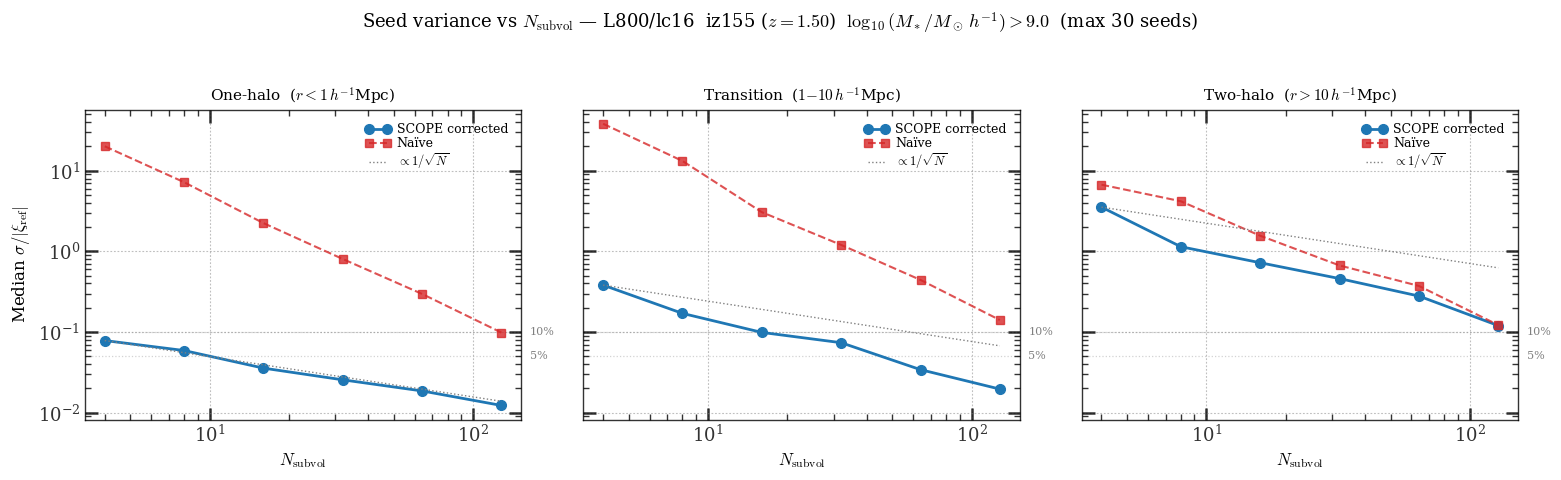

/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


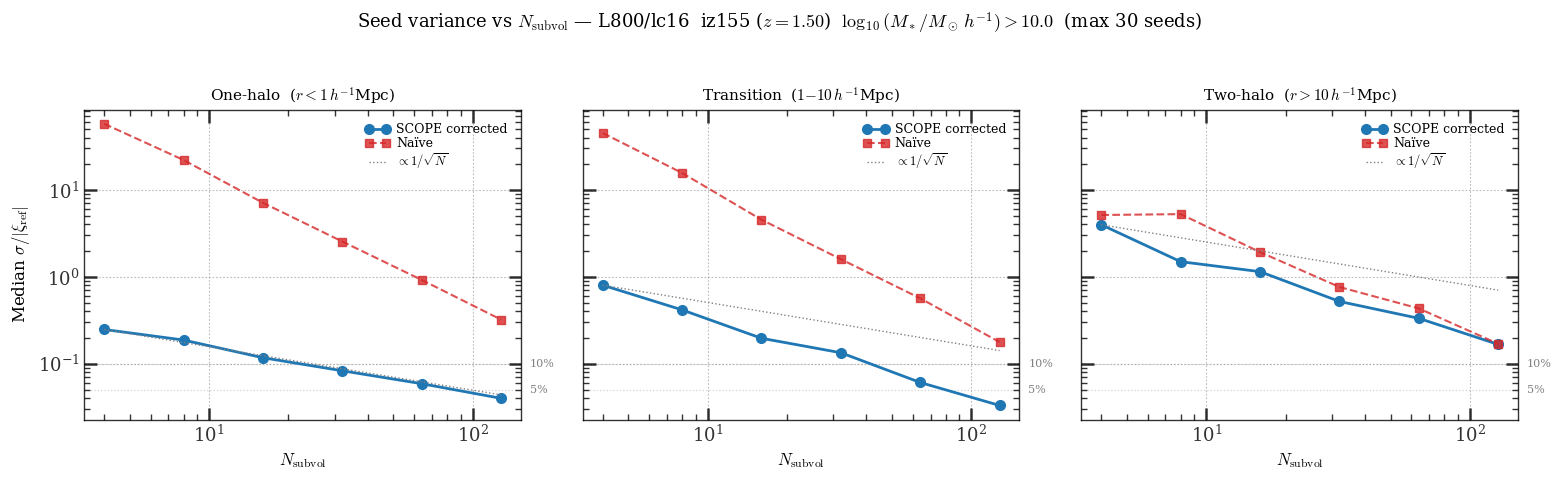

In [20]:
# ── Plot 1: σ(n) vs n — 1/√n scaling test ───────────────────────────────────

def plot_variance_vs_n(mstar_tag: str, iz: int) -> None:
    """Median σ/|ξ_ref| vs N_subvol — three r-scale panels.

    Overlays 1/√n reference.  SCOPE and naïve on the same panel to show
    whether SCOPE reduces variance in addition to correcting the bias.
    """
    vs = compute_variance_stats(iz, mstar_tag, VARIANCE_N_VALUES)
    if vs is None or vs.empty:
        print(f'No variance data: iz{iz} {mstar_tag} — run submit_scope_xi_variance.sh')
        return
    z = get_snapshot_redshift(f'iz{iz}', 'L800')
    n_seeds_max = int(vs['n_seeds'].max())

    r_bands = [
        (r'One-halo  ($r < 1\,h^{-1}$Mpc)',        lambda r: r < 1.0),
        (r'Transition  ($1{-}10\,h^{-1}$Mpc)',      lambda r: 1.0 <= r <= 10.0),
        (r'Two-halo  ($r > 10\,h^{-1}$Mpc)',        lambda r: r > 10.0),
    ]
    ns_all = sorted(vs['n_subvol'].unique())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (label, band_fn) in zip(axes, r_bands):
        sub = vs[vs['r_mid'].apply(band_fn)]
        if sub.empty:
            ax.set_title(label, fontsize=11)
            continue

        med_c = [sub[sub['n_subvol'] == n]['rel_sigma_corr'].median()  for n in ns_all]
        med_n = [sub[sub['n_subvol'] == n]['rel_sigma_naive'].median() for n in ns_all]

        ax.plot(ns_all, med_c, 'o-',  color='C0', lw=2.0, ms=7, label='SCOPE corrected')
        ax.plot(ns_all, med_n, 's--', color='C3', lw=1.5, ms=6, alpha=0.8, label='Naïve')

        # 1/√n reference anchored at first finite SCOPE point
        for mc_val, n0 in zip(med_c, ns_all):
            if np.isfinite(mc_val):
                ns_arr = np.array(ns_all)
                ax.plot(ns_arr, mc_val * np.sqrt(n0 / ns_arr),
                        color='grey', lw=1.0, ls=':', label=r'$\propto 1/\sqrt{N}$')
                break

        for thresh in [0.05, 0.10]:
            ax.axhline(thresh, color='lightgrey', lw=0.9, ls=':', zorder=0)
            ax.text(1.02, thresh, f'{thresh:.0%}',
                    transform=ax.get_yaxis_transform(),
                    fontsize=8, va='center', color='grey')

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm subvol}$', fontsize=12)
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=9)

    axes[0].set_ylabel(r'Median $\sigma/|\xi_{\rm ref}|$', fontsize=12)
    fig.suptitle(
        f'Seed variance vs $N_{{\\rm subvol}}$ — {SIM}/{MODEL}  iz{iz} ($z={z:.2f}$)  '
        f'{_mstar_label(mstar_tag)}  (max {n_seeds_max} seeds)',
        fontsize=13,
    )
    plt.tight_layout()
    tag = mstar_tag.replace('.', 'p')
    fig.savefig(VARIANCE_SAVE_DIR / f'variance_vs_n_iz{iz}_{tag}.pdf', bbox_inches='tight')
    plt.show()


for mtag in VARIANCE_MSTAR_TAGS:
    plot_variance_vs_n(mtag, VARIANCE_IZ)


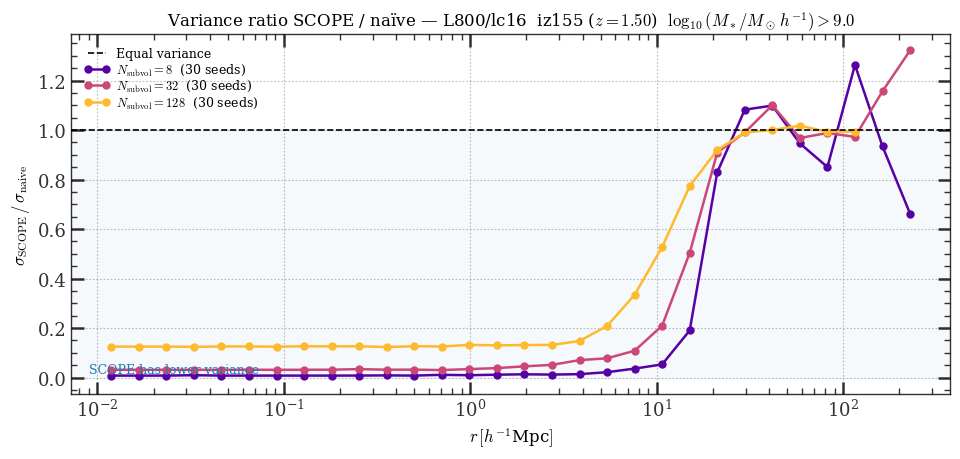

/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


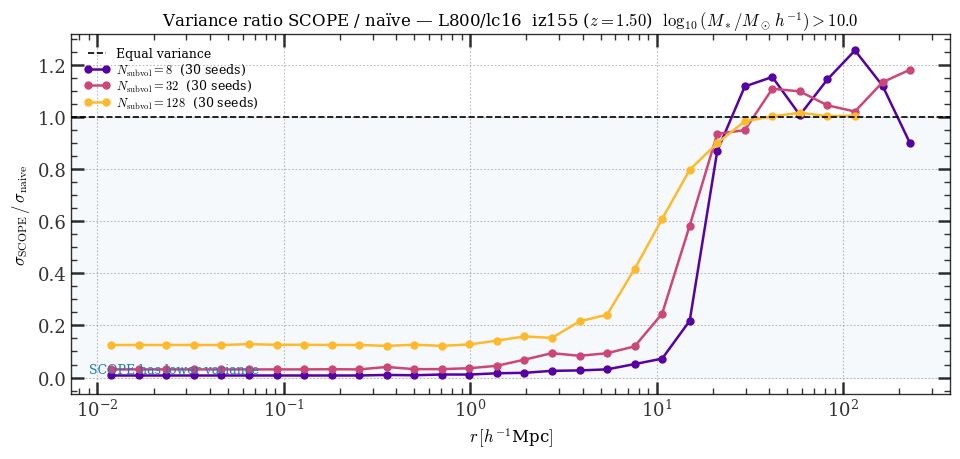

In [24]:
# ── Plot 2: σ_SCOPE / σ_naïve vs r — variance reduction by scale ─────────────

def plot_variance_ratio(mstar_tag: str, iz: int,
                        n_values: list[int] = (8, 32, 128)) -> None:
    """σ_SCOPE(r) / σ_naïve(r) as a function of separation r.

    Ratio < 1: SCOPE reduces seed-to-seed variance at that scale.
    Expectation — below 1 in the one-halo regime (SCOPE down-weights noisy
    auto-pairs), rising toward 1 in the two-halo regime.
    """
    vs = compute_variance_stats(iz, mstar_tag, VARIANCE_N_VALUES)
    if vs is None or vs.empty:
        print(f'No variance data: iz{iz} {mstar_tag}')
        return
    z       = get_snapshot_redshift(f'iz{iz}', 'L800')
    n_show  = [n for n in n_values if n in vs['n_subvol'].unique()]
    colors  = mpl.colormaps['plasma'](np.linspace(0.15, 0.85, max(len(n_show), 1)))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(1.0, color='k', lw=1.2, ls='--', zorder=5, label='Equal variance')
    ax.axhspan(0, 1, color='C0', alpha=0.04, zorder=0)

    for n, col in zip(n_show, colors):
        sub   = vs[vs['n_subvol'] == n].sort_values('r_mid')
        valid = sub[sub['variance_ratio'].notna()]
        if valid.empty:
            continue
        n_seeds = int(valid['n_seeds'].iloc[0])
        ax.plot(valid['r_mid'], valid['variance_ratio'],
                color=col, marker='o', ms=5, lw=1.8,
                label=f'$N_{{\\rm subvol}}={n}$  ({n_seeds} seeds)')

    ax.set_xscale('log')
    ax.set_xlabel(r'$r\,[h^{-1}$Mpc$]$', fontsize=12)
    ax.set_ylabel(r'$\sigma_{\rm SCOPE}\,/\,\sigma_{\rm naive}$', fontsize=12)
    ax.set_title(
        f'Variance ratio SCOPE / naïve — {SIM}/{MODEL}  iz{iz} ($z={z:.2f}$)  '
        f'{_mstar_label(mstar_tag)}',
        fontsize=12,
    )
    ax.text(0.02, 0.05, 'SCOPE has lower variance',
            transform=ax.transAxes, fontsize=9, color='C0', va='bottom')
    ax.legend(fontsize=9)
    plt.tight_layout()
    tag = mstar_tag.replace('.', 'p')
    fig.savefig(VARIANCE_SAVE_DIR / f'variance_ratio_iz{iz}_{tag}.pdf', bbox_inches='tight')
    plt.show()


for mtag in VARIANCE_MSTAR_TAGS:
    plot_variance_ratio(mtag, VARIANCE_IZ, n_values=[8, 32, 128])


/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


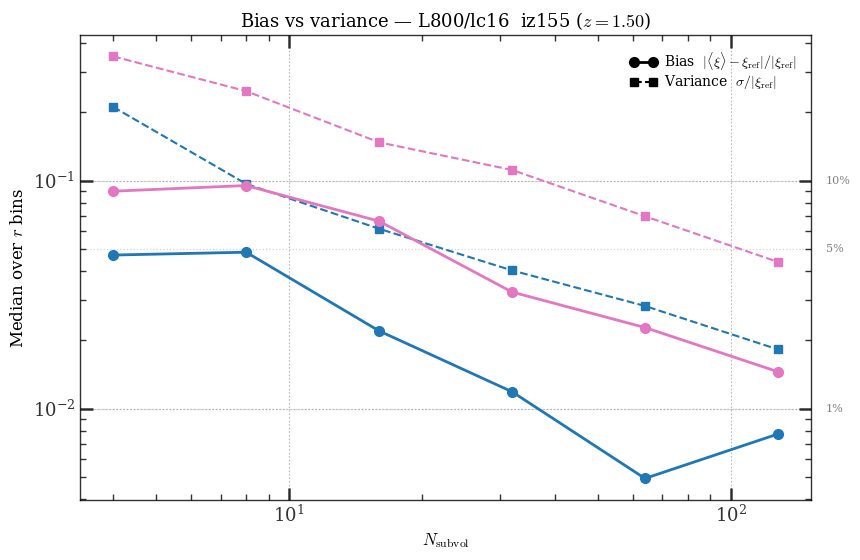

/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


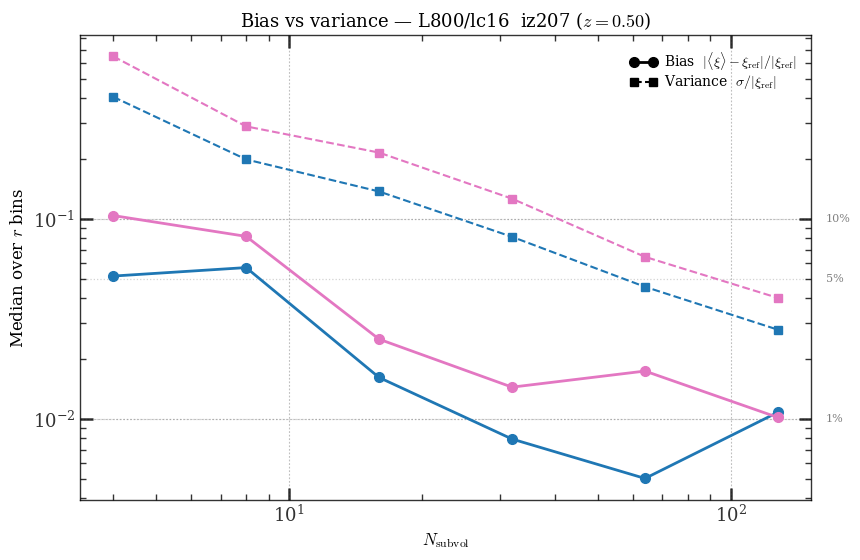

/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/cosma/apps/durham/dc-hick2/galform_analysis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


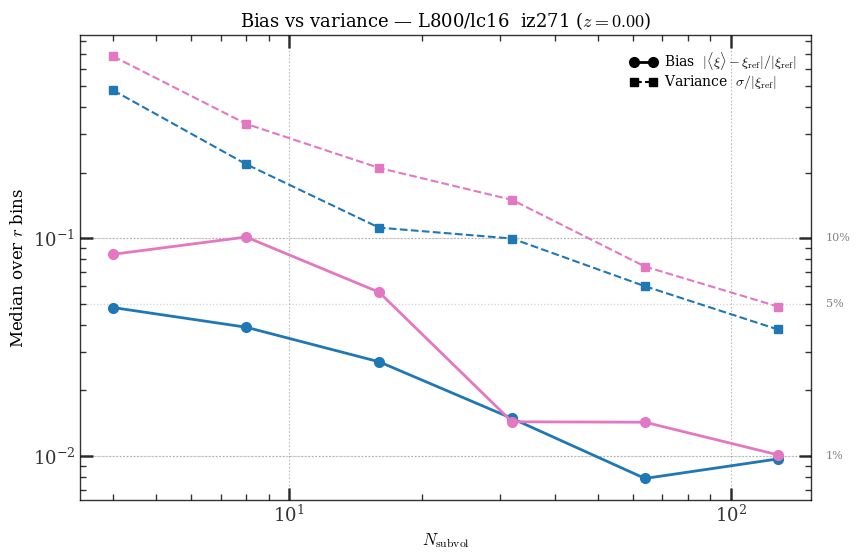

In [25]:
# ── Plot 3: bias vs variance — minimum useful N_subvol ───────────────────────

def plot_bias_variance(mstar_tags: list[str], iz: int) -> None:
    """Bias and σ on the same axes vs N_subvol.

    Bias = median |Δlog₁₀ξ| (from aggregated table).
    σ    = median σ_SCOPE / |ξ_ref| (from seed ensemble).

    The crossover n* where bias ≈ σ is the minimum sub-volume count needed
    before variance, not systematic bias, limits the estimate.
    """
    z      = get_snapshot_redshift(f'iz{iz}', 'L800')
    colors = mpl.colormaps['tab10'](np.linspace(0, 0.6, max(len(mstar_tags), 1)))

    fig, ax = plt.subplots(figsize=(9, 6))

    for mstar_tag, col in zip(mstar_tags, colors):
        g  = load_and_aggregate(iz, mstar_tag)
        vs = compute_variance_stats(iz, mstar_tag, VARIANCE_N_VALUES)
        if g is None or vs is None:
            continue

        ns = sorted(n for n in g['n_subvol'].unique()
                    if n != N_REF and n in VARIANCE_N_VALUES)
        bias_vals, sigma_vals = [], []
        for n in ns:
            sub_g = g[(g['n_subvol'] == n) & (g['xi_ref'] > 0)]
            bias_vals.append(np.nanmedian(np.abs(sub_g['dlog_corr'].dropna())))
            sigma_vals.append(vs[vs['n_subvol'] == n]['rel_sigma_corr'].median())

        lbl = _mstar_label(mstar_tag)
        ax.plot(ns, bias_vals,  color=col, marker='o', ms=7, lw=2.0,
                label=f'{lbl}  bias')
        ax.plot(ns, sigma_vals, color=col, marker='s', ms=6, lw=1.5, ls='--',
                label=f'{lbl}  σ')

    for thresh in [0.01, 0.05, 0.10]:
        ax.axhline(thresh, color='lightgrey', lw=0.9, ls=':', zorder=0)
        ax.text(1.02, thresh, f'{thresh:.0%}',
                transform=ax.get_yaxis_transform(),
                fontsize=8, va='center', color='grey')

    style_handles = [
        mpl.lines.Line2D([0],[0], color='k', lw=2.0, marker='o', ms=7,
            label=r'Bias  $|\langle\xi\rangle - \xi_{\rm ref}|/|\xi_{\rm ref}|$'),
        mpl.lines.Line2D([0],[0], color='k', lw=1.5, marker='s', ms=6, ls='--',
            label=r'Variance  $\sigma/|\xi_{\rm ref}|$'),
    ]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm subvol}$', fontsize=12)
    ax.set_ylabel('Median over $r$ bins', fontsize=12)
    ax.legend(handles=style_handles, fontsize=10, loc='upper right')
    ax.set_title(
        f'Bias vs variance — {SIM}/{MODEL}  iz{iz} ($z={z:.2f}$)',
        fontsize=13,
    )
    plt.tight_layout()
    fig.savefig(VARIANCE_SAVE_DIR / f'bias_variance_iz{iz}.pdf', bbox_inches='tight')
    plt.show()


for iz_bv in IZ_LIST:
    plot_bias_variance(VARIANCE_MSTAR_TAGS, iz_bv)


### Results

**Scaling with $N_{\rm subvol}$ (Plot 1).**
The SCOPE-corrected variance scales as $N_{\rm subvol}^{-1/2}$ across all three separation regimes, confirming that successive sub-volume draws are independent realisations of the same field. In the one-halo regime ($r < 1\,h^{-1}$Mpc) at $N=4$, the SCOPE variance is $\sigma/|\xi_{\rm ref}| \approx 8$%, while the naïve variance at the same configuration exceeds $1000$%: a factor of $\gtrsim 100$ reduction. The naïve variance also follows $1/\sqrt{N}$ but with an amplitude set by the inflated auto-pair term, which is a factor $k/m$ larger than the corrected one-halo signal (equation 6). At two-halo scales the two estimators converge to comparable variance, as expected when $\alpha \to 1$.

**Variance reduction by scale (Plot 2).**
The ratio $\sigma_{\rm SCOPE}/\sigma_{\rm naïve}$ is $\lesssim 0.05$ at $r < 1\,h^{-1}$Mpc and rises smoothly to $\approx 1$ at $r \gtrsim 15\,h^{-1}$Mpc. This confirms that the variance reduction is localised to the one-halo regime and that SCOPE carries no variance penalty at large scales. The transition scale matches the one-halo to two-halo crossing in $\xi(r)$, consistent with the picture that $\alpha$ suppresses exactly the noisiest (auto-pair) contribution.

**Bias versus variance (Plot 3).**
For both stellar-mass selections, the SCOPE bias (solid lines) lies approximately an order of magnitude below the variance (dashed lines) at every $N_{\rm subvol}$ tested. The crossover point $N^*$ at which $|{\rm bias}| = \sigma$ therefore lies at $N < 4$, below the range probed here. This implies that for any practically useful sub-volume count, the statistical uncertainty of the SCOPE estimator dominates over its systematic bias: the correction is not the limiting factor for inference. The estimator is simultaneously nearly unbiased and close to minimum-variance in the one-halo regime.
